In [53]:
import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder
from xgboost import XGBRegressor  # Or RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error

In [38]:
df = pd.read_csv("data.csv")

In [39]:
df['Target_Inflation_Rate']=1-df['Disposable_Income']/df['Income']
y = df["Target_Inflation_Rate"]

X_engineered = pd.DataFrame()

# Categorical features can stay as they are for demographic context
X_engineered["Occupation"] = df["Occupation"]
X_engineered["City_Tier"] = df["City_Tier"]
X_engineered["Age"] = df["Age"]
X_engineered["Dependents"] = df["Dependents"]

In [40]:
expense_columns = [
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
]

In [41]:
for col in expense_columns:
    X_engineered[f"{col}_Ratio"] = df[col] / df["Income"]

    # Do the exact same thing for the potential savings values
    if f"Potential_Savings_{col}" in df.columns:
        if col!="Miscellaneous" and col!="Utilities":
            X_engineered[f"Potential_Savings_{col}_Ratio"] = (
                df[f"Potential_Savings_{col}"] / df["Income"]
            )

In [42]:
categorical_features = ["Occupation", "City_Tier"]
numerical_features = [
    col for col in X_engineered.columns if col not in categorical_features
]
numerical_features

['Age',
 'Dependents',
 'Rent_Ratio',
 'Loan_Repayment_Ratio',
 'Insurance_Ratio',
 'Groceries_Ratio',
 'Potential_Savings_Groceries_Ratio',
 'Transport_Ratio',
 'Potential_Savings_Transport_Ratio',
 'Eating_Out_Ratio',
 'Potential_Savings_Eating_Out_Ratio',
 'Entertainment_Ratio',
 'Potential_Savings_Entertainment_Ratio',
 'Utilities_Ratio',
 'Healthcare_Ratio',
 'Potential_Savings_Healthcare_Ratio',
 'Education_Ratio',
 'Potential_Savings_Education_Ratio']

In [54]:
preprocessor=ColumnTransformer(
    transformers=[
        ('scaler',StandardScaler(),numerical_features),
        ('onehotEncoding',OneHotEncoder(handle_unknown="ignore",sparse_output=False),[categorical_features[0]]),
        ('ordinalEncoding',OrdinalEncoder(categories=[['Tier_3','Tier_2','Tier_1']]),[categorical_features[1]])
])

In [55]:
pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            XGBRegressor(
               objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
            ),
        ),
    ]
)


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)
pipeline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('onehotEncoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
y_pred=pipeline.predict(X_test)

In [59]:
print("XGBoost Model \n")
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

XGBoost Model 

MAE: 0.0059
R² Score: 0.9944


In [60]:
import shap
shap.initjs()
explainer=shap.TreeExplainer(pipeline["model"],pipeline["preprocess"].transform(X_train))
shap_values=explainer.shap_values(pipeline["preprocess"].transform(X_test))

 99%|===================| 3956/4000 [00:50<00:00]        

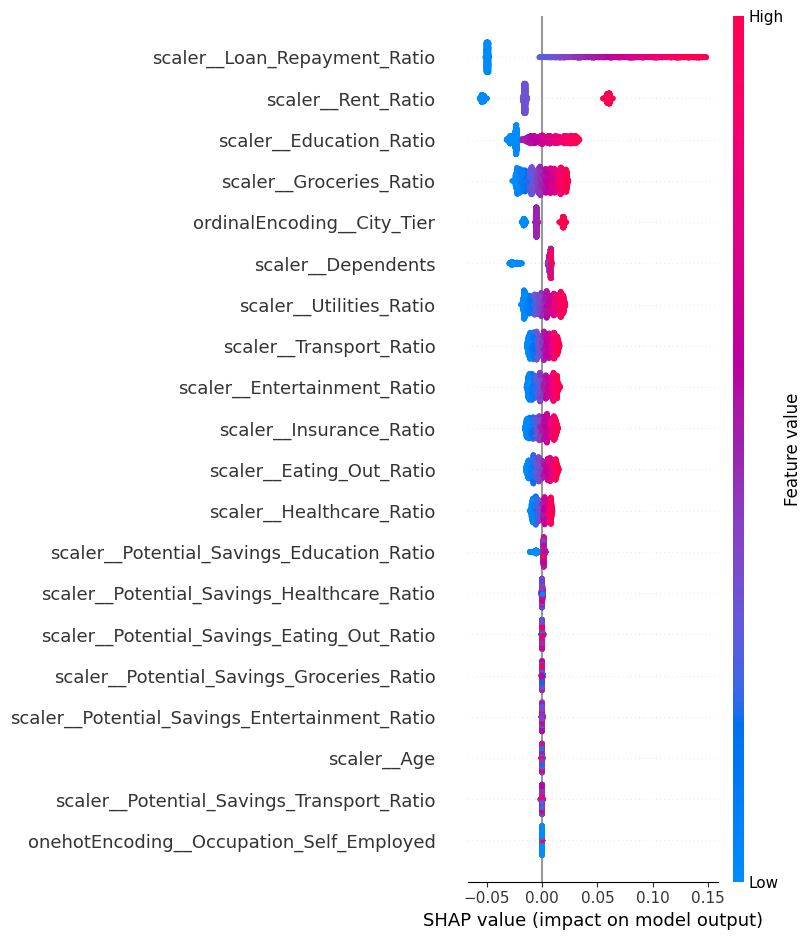

In [61]:
shap.summary_plot(shap_values,pipeline["preprocess"].transform(X_test),feature_names=pipeline["preprocess"].get_feature_names_out())

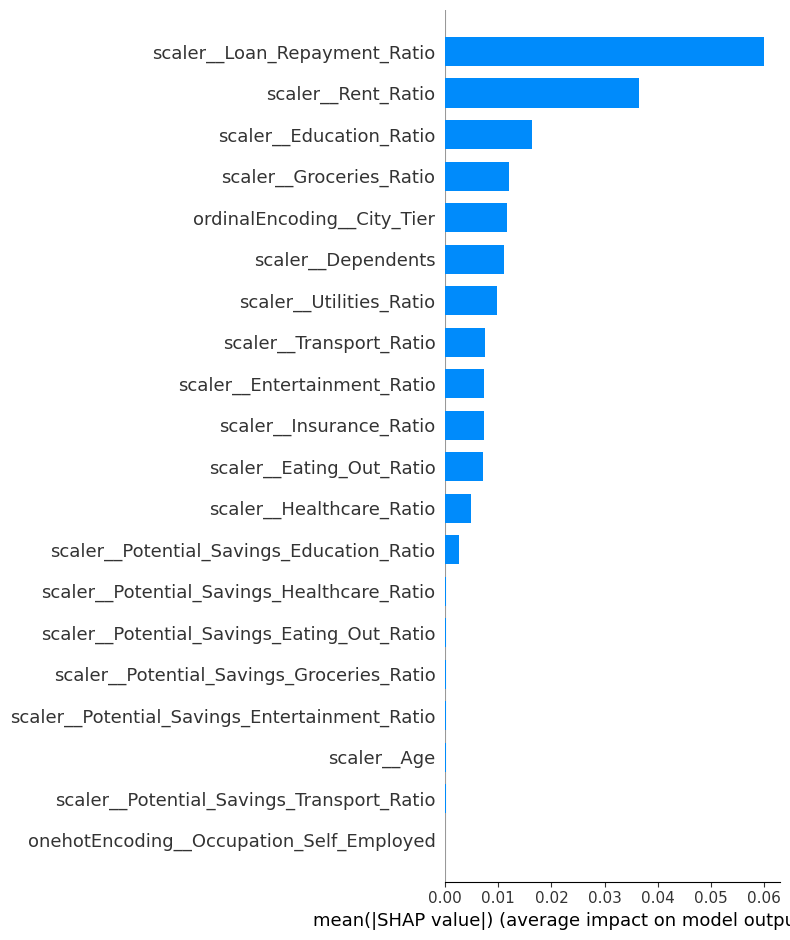

In [62]:
shap.summary_plot(shap_values,pipeline["preprocess"].transform(X_test),feature_names=pipeline["preprocess"].get_feature_names_out(),plot_type="bar")

In [51]:
joblib.dump(pipeline, "model.joblib")
print("Model trained successfully with proportion vectors!")

Model trained successfully with proportion vectors!
